In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np

from omegaconf import OmegaConf
from cgnn.process_data import process_hospitalization_data, get_cbsa_list
from cgnn.explain import load_aggregate_ts_from_cfg, compute_lead_lag
from cgnn.plot import _set_size

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator
from matplotlib.lines import Line2D
import matplotlib.transforms as mtransforms


In [33]:
mpl.rcParams.update({
  # Font
  "font.family":       "sans-serif",
  "font.sans-serif":   ["Nimbus Sans"],
  "font.size":         9,
  "mathtext.fontset":  "custom",
  "mathtext.rm":       "Nimbus Sans",
  "mathtext.it":       "Nimbus Sans:italic",

  # Axes
  "axes.linewidth":    0.8,
  "axes.labelsize":    9,
  "axes.titlesize":    10,
  "axes.titleweight":  "normal",

  # Ticks
  "xtick.labelsize":   8,
  "ytick.labelsize":   8,
  "xtick.major.width": 0.6,
  "ytick.major.width": 0.6,
  "xtick.major.size":  3.0,
  "ytick.major.size":  3.0,
  "xtick.direction":   "out",
  "ytick.direction":   "out",

  # Lines
  "lines.linewidth":   1.2,

  # Grid
  "grid.linewidth":    0.4,
  "grid.alpha":        0.5,

  # Output
  "figure.dpi":        150,
  "savefig.dpi":       300,
  "savefig.bbox":      "tight",
  "pdf.fonttype":      42,   # embeds fonts as Type 42 — required by most journals
  "ps.fonttype":       42,
})


# Figure 1 - CCF

In [12]:
# HOSP_CFG_FILE = "/burg/apam/users/nhw2114/repos/cgnn/models/gcn_checkpoints/hospital_advan_plus_full_cdcrnn_x_log1p_y_log1p_h1_lr1e-05_hs16_epochs20000/config.yaml"
# HOSP_VERSION_DIR = "/burg/apam/users/nhw2114/repos/cgnn/plots/explainer_lr0.01_epochs2000"

HOSP_CFG_FILE = "/burg/apam/users/nhw2114/repos/cgnn/models/gcn_checkpoints/hospital_advan_plus_cdcrnn_h1_lr1e-05_hs16/config.yaml"
HOSP_VERSION_DIR = "/burg/apam/users/nhw2114/repos/cgnn/plots/hospital_advan_plus_cdcrnn_h1_lr1e-05_hs16_rerun_explainer_lr0.01_epochs200"

CASE_CFG_FILE = "/burg/apam/users/nhw2114/repos/cgnn/models/gcn_checkpoints/case_advan_plus_cdcrnn_h1_lr1e-05_hs16/config.yaml"
CASE_VERSION_DIR = "/burg/apam/users/nhw2114/repos/cgnn/plots/case_advan_plus_cdcrnn_h1_lr1e-05_hs16_rerun_explainer_lr0.01_epochs200"

hosp_explain_count_df = pd.read_csv(f"{HOSP_VERSION_DIR}/explain_count.csv")
case_explain_count_df = pd.read_csv(f"{CASE_VERSION_DIR}/explain_count.csv")

In [13]:
# %%time
# hosp_ts, hosp_dates = load_aggregate_ts_from_cfg(HOSP_CFG_FILE)
# case_ts, case_dates = load_aggregate_ts_from_cfg(CASE_CFG_FILE)

In [14]:
hosp_lags, hosp_corrs, hosp_best_lag, hosp_best_corr = compute_lead_lag(hosp_explain_count_df.num_explainable_edges.values, hosp_ts, max_lag=26)
_, case_corrs, case_best_lag, case_best_corr = compute_lead_lag(case_explain_count_df.num_explainable_edges.values, case_ts, max_lag=26)

In [15]:
# Okabe-Ito palette
COLOR_STEM     = "#999999"
COLOR_TS       = "#4477AA"
COLOR_TS_CASES = "#228833"
COLOR_EDGE     = "#EE6677"
COLOR_BEST     = "#EE6677"

In [31]:
import matplotlib.transforms as mtransforms
import matplotlib.dates as mdates

peak_dict = {
    ('2020-11-16', 15565): ('2021-01-04', 647347.),
    ('2021-08-16', 13164): ('2021-09-06', 530494.),
    ('2021-12-27', 19922): ('2022-01-17', 725938),
}

def annotate_lag_pairs(ax, ax2, peak_dict, y_level=0.91,
                       color_edge=COLOR_EDGE, color_hosp=COLOR_TS):
    """
    Draw lead-lag annotations on a dual-axis time-series panel.

    Dashed vertical lines run from each peak value up to the annotation
    arrow, using axes-fraction for ymin so that peaks on two different
    y-axes (ax = hosp left, ax2 = edge right) are correctly positioned.

    Parameters
    ----------
    ax         : left Axes  (hospitalization series)
    ax2        : right Axes (edge-count series, twinx of ax)
    peak_dict  : {(edge_date, edge_val): (hosp_date, hosp_val)}
    y_level    : float, annotation height in axes-fraction coordinates
    """
    trans = mtransforms.blended_transform_factory(ax.transData, ax.transAxes)

    def _to_frac(axes, y_data):
        """Convert a data-coordinate y value to axes fraction [0, 1]."""
        y0, y1 = axes.get_ylim()
        return (float(y_data) - y0) / (y1 - y0)

    for (edge_str, edge_val), (hosp_str, hosp_val) in peak_dict.items():
        t_edge = pd.Timestamp(edge_str)
        t_hosp = pd.Timestamp(hosp_str)

        weeks = round(abs((t_hosp - t_edge).days) / 7)
        t_lo  = min(t_edge, t_hosp)
        t_hi  = max(t_edge, t_hosp)
        t_mid = t_lo + (t_hi - t_lo) / 2

        x_lo  = mdates.date2num(t_lo)
        x_hi  = mdates.date2num(t_hi)
        x_mid = mdates.date2num(t_mid)

        # Convert each peak to axes-fraction on its own axis
        ymin_edge = _to_frac(ax2, edge_val)   # edge value lives on right axis
        ymin_hosp = _to_frac(ax,  hosp_val)   # hosp value lives on left axis

        # ── dashed vertical markers, starting at the peak, ending at arrow ─
        ax.axvline(t_edge, ymin=ymin_edge, ymax=y_level,
                   color='#333333', lw=0.8, ls='--', alpha=0.5, zorder=3)
        ax.axvline(t_hosp, ymin=ymin_hosp, ymax=y_level,
                   color='#333333', lw=0.8, ls='--', alpha=0.5, zorder=3)

        # ── double-headed arrow ───────────────────────────────────────────
        ax.annotate(
            '',
            xy=(x_hi, y_level), xytext=(x_lo, y_level),
            xycoords=trans, textcoords=trans,
            arrowprops=dict(
                arrowstyle='|-|,widthA=0.3,widthB=0.3',
                color='#333333',
                lw=0.9,
                shrinkA=0, shrinkB=0,
                mutation_scale=9,
            ),
            zorder=4,
        )

        # ── centered week-count label ─────────────────────────────────────
        ax.text(
            x_mid, y_level + 0.03,
            f'+{weeks} wks',
            ha='center', va='bottom',
            fontsize=9, color='#333333',
            transform=trans,
            zorder=5,
        )


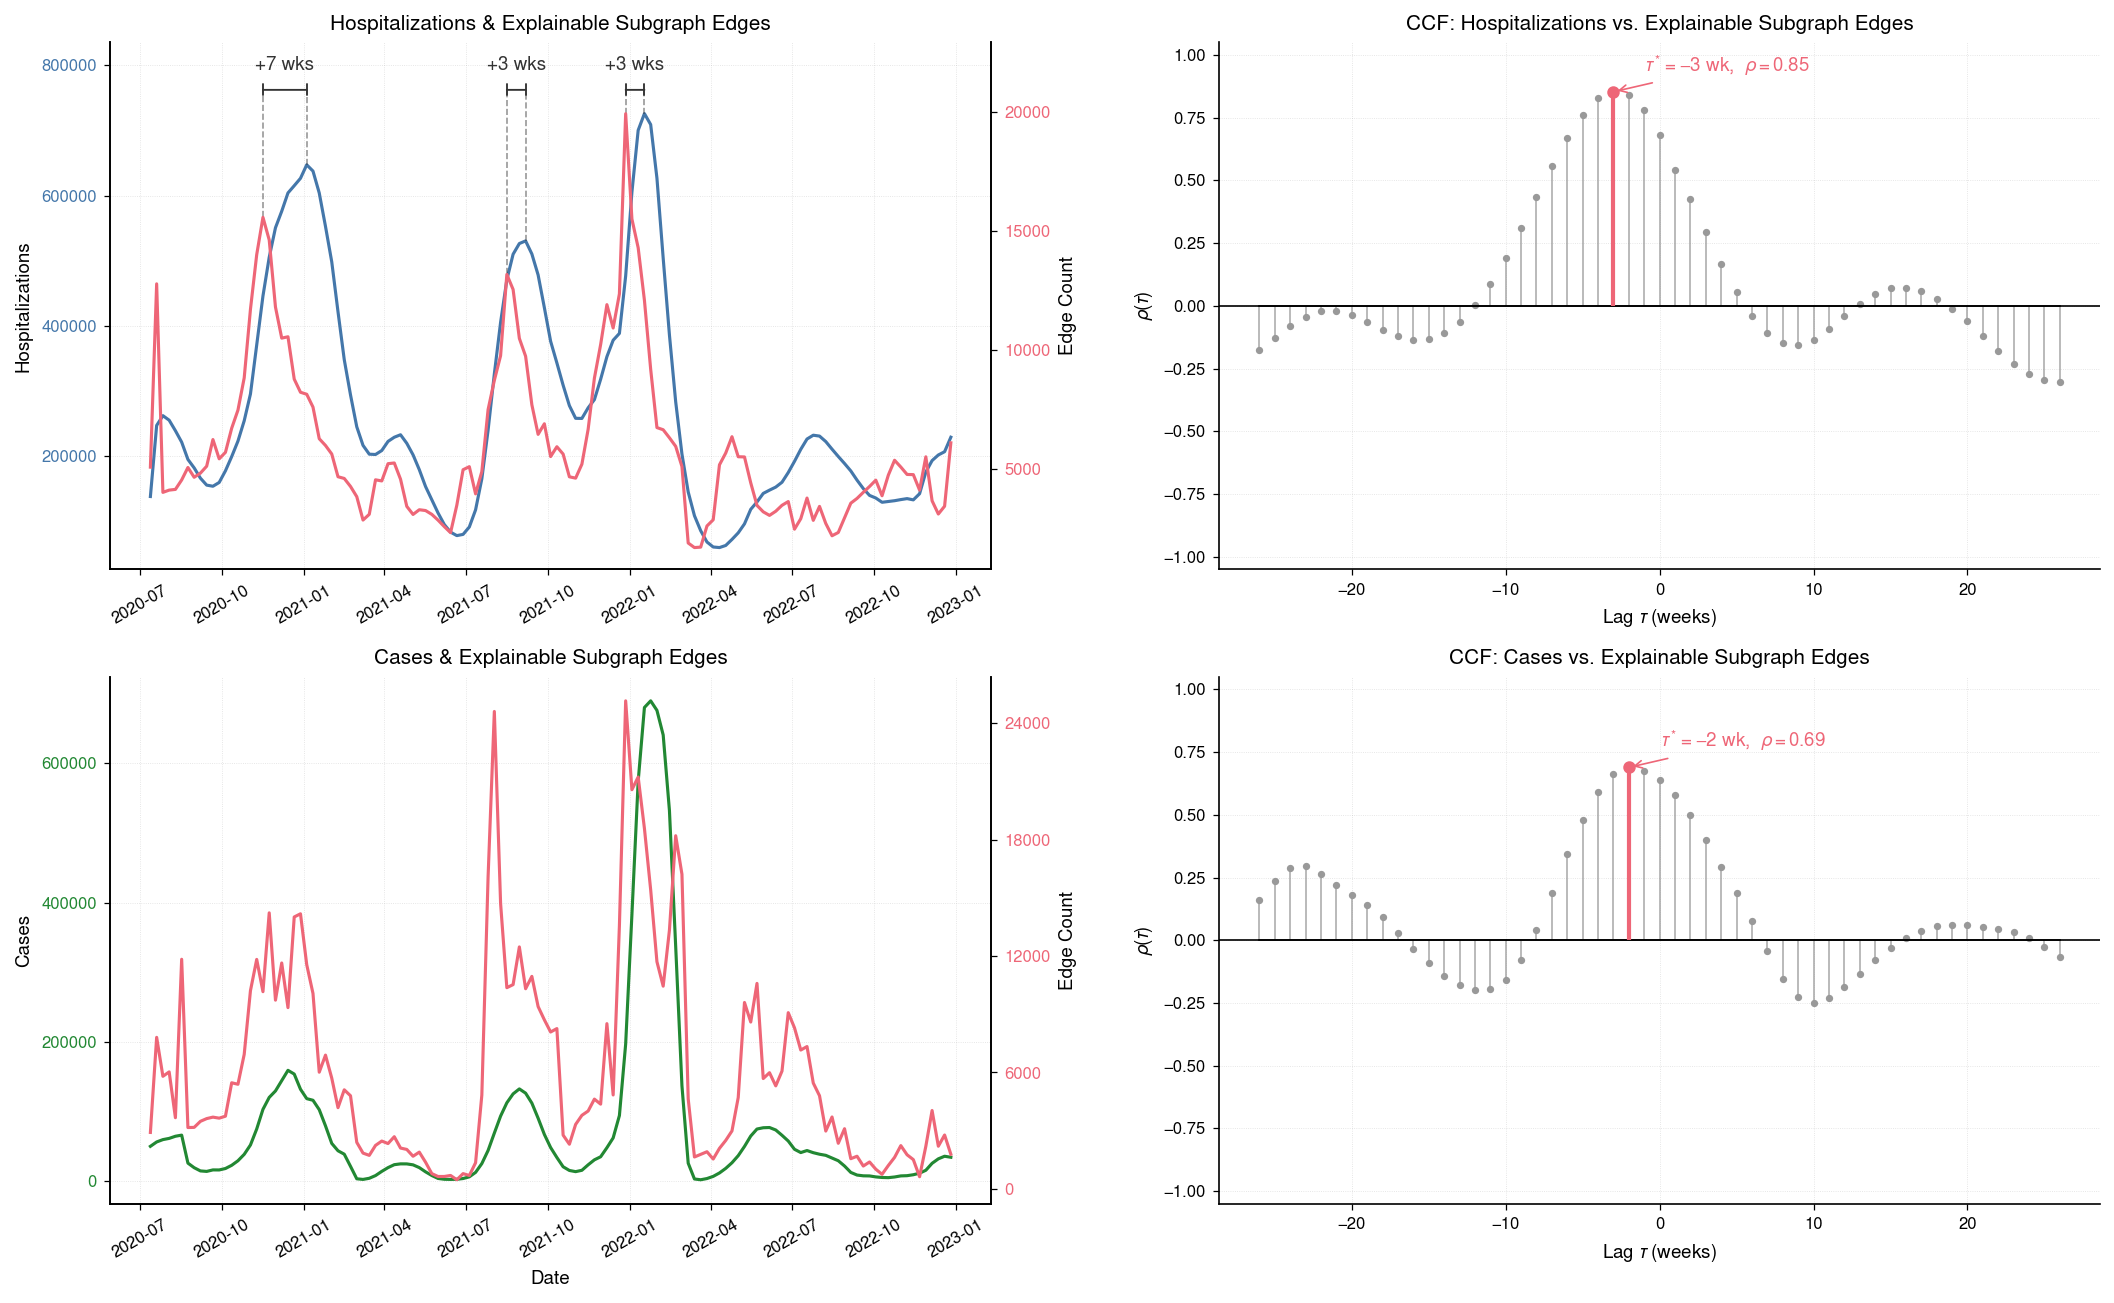

In [37]:

# Okabe-Ito palette
COLOR_STEM     = "#999999"
COLOR_TS       = "#4477AA"   # hospitalizations — deep blue
COLOR_TS_CASES = "#228833"   # cases — bluish green
COLOR_EDGE     = "#EE6677"   # edge count — vermillion
COLOR_BEST     = "#EE6677"

fig, axs = plt.subplots(2, 2, figsize=_set_size(1024))

def _fmt_date_axis(ax):
    ax.tick_params(axis="x", labelsize=8, rotation=30)

# ── Top-left: hospitalizations + explainable edges ───────────────────────
ax = axs[0, 0]
ax.plot(hosp_dates, hosp_ts, color=COLOR_TS, linewidth=1.5)
ax.set_ylabel("Hospitalizations", fontsize=9)
ax.tick_params(axis="y", labelcolor=COLOR_TS)
ax.yaxis.set_major_locator(MaxNLocator(5))
ax.set_title("Hospitalizations & Explainable Subgraph Edges", fontsize=10)
ax.grid(True, linestyle=":", alpha=0.4)
_fmt_date_axis(ax)
ax.spines['top'].set_visible(False)

ax2_hosp = ax.twinx()
ax2_hosp.plot(hosp_dates, hosp_explain_count_df.num_explainable_edges.values[:len(hosp_dates)],
              color=COLOR_EDGE, linewidth=1.5)
ax2_hosp.set_ylabel("Edge Count", fontsize=9)
ax2_hosp.tick_params(axis="y", labelcolor=COLOR_EDGE)
ax2_hosp.yaxis.set_major_locator(MaxNLocator(5))
ax2_hosp.spines['top'].set_visible(False)
_scale = 1.1                                                                                                                      
axs[0, 0].set_ylim(top=axs[0, 0].get_ylim()[1] * _scale)                                                                            
ax2_hosp.set_ylim(top=ax2_hosp.get_ylim()[1] * _scale)

# ── Bottom-left: cases + explainable edges ───────────────────────────────
ax = axs[1, 0]
ax.plot(case_dates, case_ts, color=COLOR_TS_CASES, linewidth=1.5)
ax.set_ylabel("Cases", fontsize=9)
ax.tick_params(axis="y", labelcolor=COLOR_TS_CASES)
ax.yaxis.set_major_locator(MaxNLocator(5))
ax.set_title("Cases & Explainable Subgraph Edges", fontsize=10)
ax.set_xlabel("Date", fontsize=9)
ax.grid(True, linestyle=":", alpha=0.4)
_fmt_date_axis(ax)
ax.spines['top'].set_visible(False)

n_case = len(case_explain_count_df)
ax2 = ax.twinx()
ax2.plot(case_dates[:n_case], case_explain_count_df.num_explainable_edges.values,
         color=COLOR_EDGE, linewidth=1.5)
ax2.set_ylabel("Edge Count", fontsize=9)
ax2.tick_params(axis="y", labelcolor=COLOR_EDGE)
ax2.yaxis.set_major_locator(MaxNLocator(5))
ax2.spines['top'].set_visible(False)

# ── Top-right: hospitalizations cross-correlogram ────────────────────────
ax = axs[0, 1]
markerline, stemlines, baseline = ax.stem(hosp_lags, hosp_corrs, linefmt="-", markerfmt="o", basefmt="k-")
plt.setp(stemlines, color=COLOR_STEM, linewidth=0.8, alpha=0.8)
plt.setp(markerline, color=COLOR_STEM, markersize=2.5)
plt.setp(baseline, linewidth=0.8, color="black")

best_idx = np.argmax(np.abs(hosp_corrs))
ax.vlines(hosp_best_lag, 0, hosp_corrs[best_idx], color=COLOR_BEST, linewidth=2.0, zorder=5)
ax.plot(hosp_best_lag, hosp_corrs[best_idx], "o", color=COLOR_BEST, markersize=5, zorder=6)
offset = 2 if hosp_best_lag < 20 else -10
ax.annotate(
    f"$\\tau^* = {hosp_best_lag}$ wk,  $\\rho = {hosp_best_corr:.2f}$",
    xy=(hosp_best_lag, hosp_corrs[best_idx]),
    xytext=(hosp_best_lag + offset, hosp_corrs[best_idx] + 0.08),
    fontsize=9, color=COLOR_BEST,
    arrowprops=dict(arrowstyle="->", color=COLOR_BEST, lw=0.8),
)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Lag $\\tau$ (weeks)", fontsize=9)
ax.set_ylabel("$\\rho(\\tau)$", fontsize=9)
ax.set_title("CCF: Hospitalizations vs. Explainable Subgraph Edges", fontsize=10)
ax.set_ylim(-1.05, 1.05)
ax.grid(True, linestyle=":", alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ── Bottom-right: cases cross-correlogram ────────────────────────────────
ax = axs[1, 1]
markerline, stemlines, baseline = ax.stem(hosp_lags, case_corrs, linefmt="-", markerfmt="o", basefmt="k-")
plt.setp(stemlines, color=COLOR_STEM, linewidth=0.8, alpha=0.8)
plt.setp(markerline, color=COLOR_STEM, markersize=2.5)
plt.setp(baseline, linewidth=0.8, color="black")

best_idx_case = np.argmax(np.abs(case_corrs))
ax.vlines(case_best_lag, 0, case_corrs[best_idx_case], color=COLOR_BEST, linewidth=2.0, zorder=5)
ax.plot(case_best_lag, case_corrs[best_idx_case], "o", color=COLOR_BEST, markersize=5, zorder=6)
offset = 2 if case_best_lag < 20 else -10
ax.annotate(
    f"$\\tau^* = {case_best_lag}$ wk,  $\\rho = {case_best_corr:.2f}$",
    xy=(case_best_lag, case_corrs[best_idx_case]),
    xytext=(case_best_lag + offset, case_corrs[best_idx_case] + 0.08),
    fontsize=9, color=COLOR_BEST,
    arrowprops=dict(arrowstyle="->", color=COLOR_BEST, lw=0.8),
)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Lag $\\tau$ (weeks)", fontsize=9)
ax.set_ylabel("$\\rho(\\tau)$", fontsize=9)
ax.set_title("CCF: Cases vs. Explainable Subgraph Edges", fontsize=10)
ax.set_ylim(-1.05, 1.05)
ax.grid(True, linestyle=":", alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ── Peak-lag annotations on the hospitalization panel ────────────────────
annotate_lag_pairs(axs[0, 0], ax2_hosp, peak_dict)

fig.tight_layout(w_pad=3.0)
# plt.savefig("fig1_ccf.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
from scipy.signal import argrelextrema

# Compute local maxima for hospitalizations
hosp_ts_arr = np.array(hosp_ts)
hosp_local_max_idx = argrelextrema(hosp_ts_arr, np.greater, order=2)[0]
hosp_max_dates = [hosp_dates[i] for i in hosp_local_max_idx]

# Compute local maxima for number of explainable edges
explain_edges_arr = np.array(hosp_explain_count_df.num_explainable_edges.values)
explain_edges_local_max_idx = argrelextrema(explain_edges_arr, np.greater, order=2)[0]
explain_edges_max_dates = [hosp_dates[i] for i in explain_edges_local_max_idx]

# Plot both time series with maxima marked
fig, ax1 = plt.subplots(figsize=(10, 5))

COLOR_HOSP = "#2572B5"
COLOR_EXPLAIN = "#E97A3A"

ln1 = ax1.plot(hosp_dates, hosp_ts, label="Hospitalizations", color=COLOR_HOSP)
ax1.scatter([hosp_dates[i] for i in hosp_local_max_idx],
            [hosp_ts_arr[i] for i in hosp_local_max_idx],
            marker="*", color=COLOR_HOSP, s=100, label="Hosp Maxima")
ax1.set_ylabel("Aggregate Hospitalizations", color=COLOR_HOSP)
ax1.tick_params(axis='y', labelcolor=COLOR_HOSP)

ax2 = ax1.twinx()
ln2 = ax2.plot(hosp_dates, hosp_explain_count_df.num_explainable_edges.values,
               label="Explainable Edges", color=COLOR_EXPLAIN)
ax2.scatter([hosp_dates[i] for i in explain_edges_local_max_idx],
            [explain_edges_arr[i] for i in explain_edges_local_max_idx],
            marker="*", color=COLOR_EXPLAIN, s=100, label="Edge Maxima")
ax2.set_ylabel("Explainable Edges", color=COLOR_EXPLAIN)
ax2.tick_params(axis='y', labelcolor=COLOR_EXPLAIN)

# Legend handling
lns = ln1 + ln2
labels = [l.get_label() for l in lns]
ax1.legend(lns + [ax1.collections[0], ax2.collections[0]],
           ['Hospitalizations', 'Explainable Edges', 'Hosp Maxima', 'Edge Maxima'],
           loc='upper left', fontsize=9)

ax1.set_xlabel("Date")
ax1.set_title("Local Maxima in Hospitalizations and Explainable Edges (Marked by *)")

fig.tight_layout()
plt.show()

# Also print the lists of maxima dates
print("Hospitalization local maxima dates:")
print([(hosp_max_dates[i], hosp_ts_arr[idx]) for i, idx in enumerate(hosp_local_max_idx)])
print("Explainable edge local maxima dates:")
for i, idx in enumerate(explain_edges_local_max_idx):
    print(explain_edges_max_dates[i], explain_edges_arr[idx])

# Figure 2 - HHS plots

In [10]:
from cgnn.dataloader import ConfigurableDatasetLoader

# Load per-edge explanation data for HHS breakdown
explain_edges_df = pd.read_csv(
    f"{HOSP_VERSION_DIR}/explain_edges.csv",
    dtype={'cbsa_orig': str, 'cbsa_dest': str}
)
explain_edges_df['date'] = pd.to_datetime(explain_edges_df['date'])

# Build per-HHS edge count dicts (out, into, within)
out_hhs_dict = {}
into_hhs_dict = {}
within_hhs_dict = {}

for hhs in range(1, 11):
    hhs_str = str(hhs)
    region_cbsas = set(get_cbsa_list(hhs_region=hhs_str))
    orig_in = explain_edges_df['cbsa_orig'].isin(region_cbsas)
    dest_in = explain_edges_df['cbsa_dest'].isin(region_cbsas)
    out_hhs_dict[hhs_str]    = explain_edges_df.loc[ orig_in & ~dest_in].groupby('date').size()
    into_hhs_dict[hhs_str]   = explain_edges_df.loc[~orig_in &  dest_in].groupby('date').size()
    within_hhs_dict[hhs_str] = explain_edges_df.loc[ orig_in &  dest_in].groupby('date').size()

# Load per-CBSA hospitalization data and aggregate by HHS
raw_cfg = OmegaConf.load(HOSP_CFG_FILE)
loader = ConfigurableDatasetLoader(cfg=raw_cfg)
hosp_data_df  = loader.data_df
hosp_col_name = loader.target_col
date_col_name = loader.date_col

agg_hhs_hosp = {}
for hhs in range(1, 11):
    hhs_str = str(hhs)
    region_cbsas = set(get_cbsa_list(hhs_region=hhs_str))
    region_df = hosp_data_df[hosp_data_df['CBSA'].isin(region_cbsas)]
    agg_hhs_hosp[hhs_str] = (
        region_df
        .groupby(date_col_name)[hosp_col_name]
        .sum()
        .sort_index()
    )

Loading hospitalization data...


/burg-archive/apam/users/nhw2114/repos/cgnn/src/cgnn/process_data.py:988: DtypeWarning: Columns (0: hospital_pk, 1: ccn) have mixed types. Specify dtype option on import or set low_memory=False.
  hosp_df = pd.read_csv(raw_hospitalization_file, dtype={"fips_code": str})


number of hospitals with less than max_missing_weeks=21 missing weeks: 4930
unique ZIPs in zip-cbsa map: 39502
unique ZIPs in zip-county map: 39490
num zips in cbsa but not county: 15
num zips in county but not cbsa: 3
Loading mobility data (source=advan_plus)...


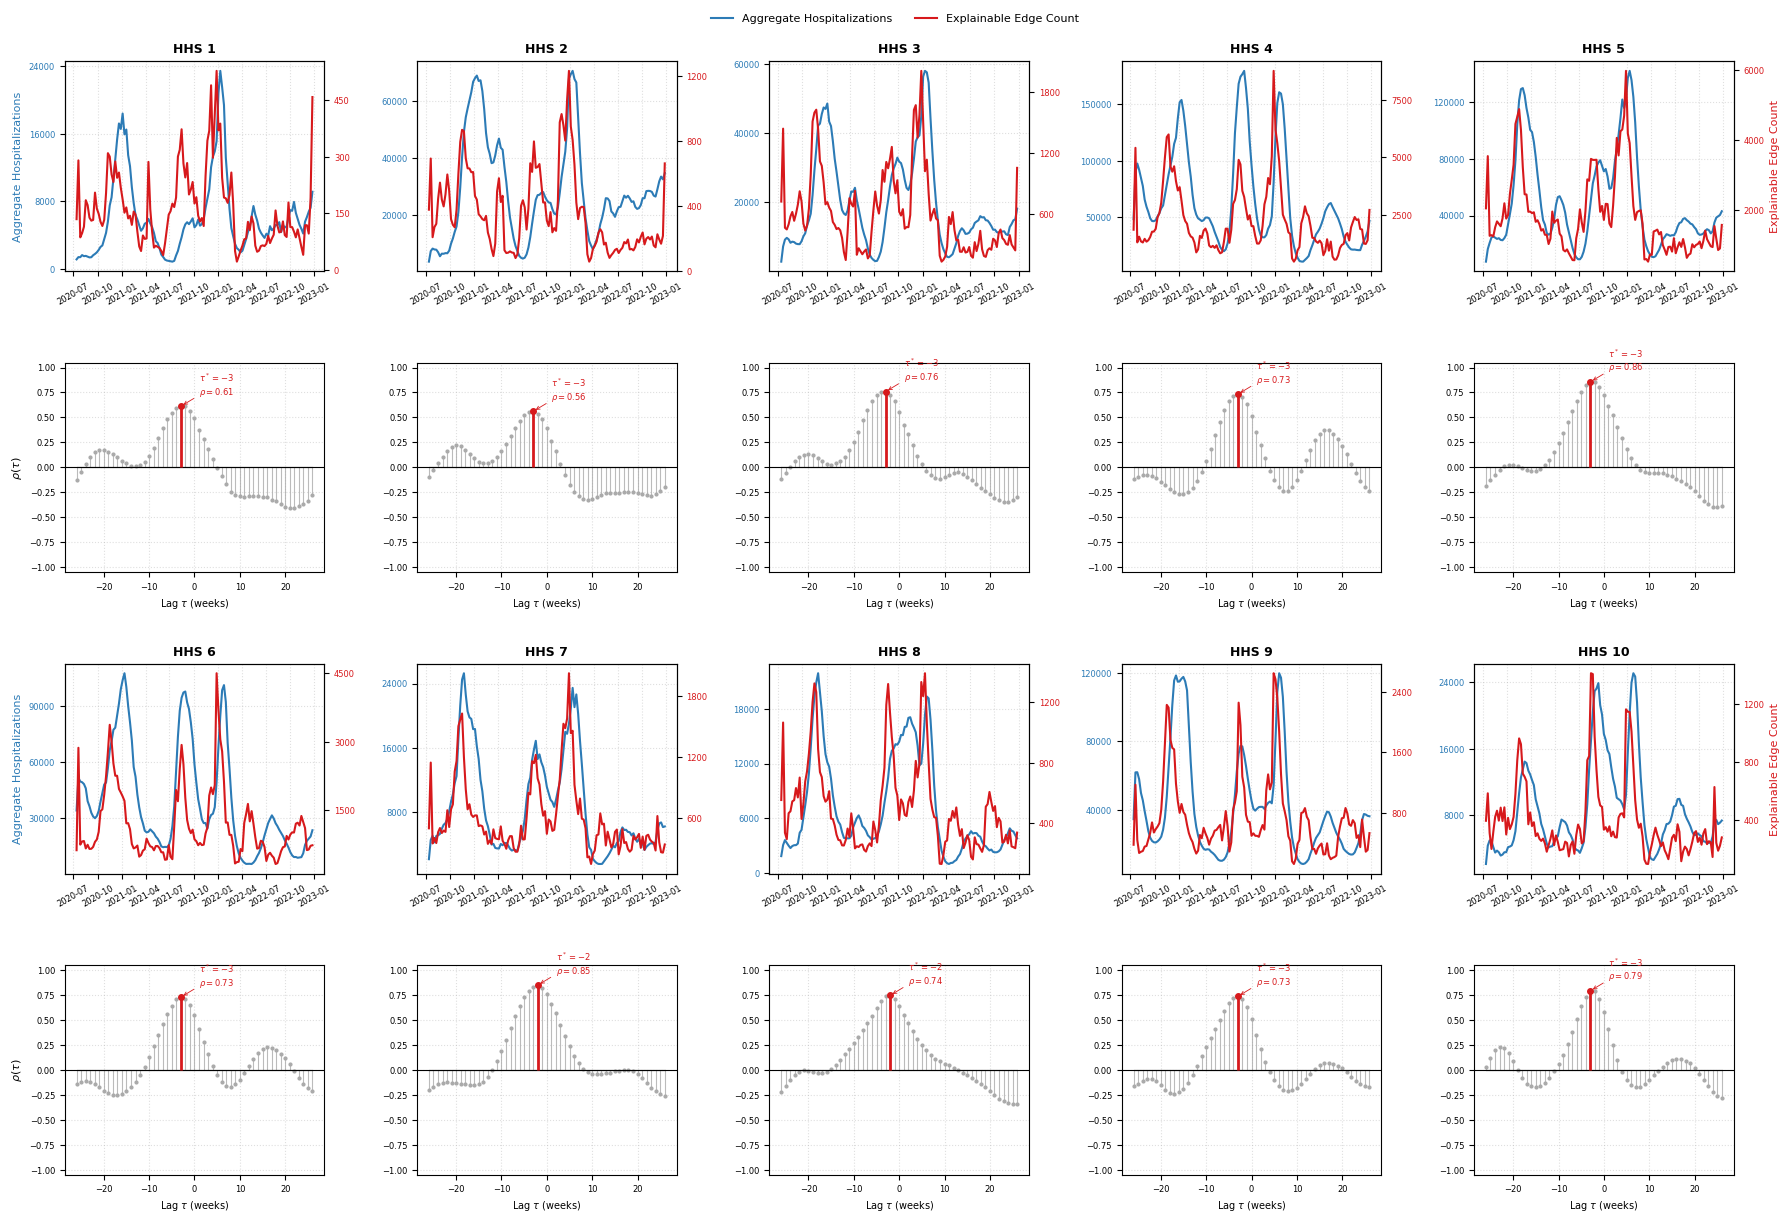

In [11]:
dates_dt = pd.to_datetime(hosp_dates)

fig, axs = plt.subplots(4, 5, figsize=(18, 12))

# Row offsets: HHS 1-5 occupy rows 0-1, HHS 6-10 occupy rows 2-3
ROW_OFFSETS = {hhs: (0 if hhs <= 5 else 2) for hhs in range(1, 11)}
COL_IDX     = {hhs: (hhs - 1) % 5        for hhs in range(1, 11)}

for hhs in range(1, 11):
    hhs_str  = str(hhs)
    row_off  = ROW_OFFSETS[hhs]
    col      = COL_IDX[hhs]
    ax_ts    = axs[row_off,     col]
    ax_ccf   = axs[row_off + 1, col]

    # Total per-HHS edge count (used for CCF and time series)
    total_edges = (
        within_hhs_dict[hhs_str]
        .add(out_hhs_dict[hhs_str],  fill_value=0)
        .add(into_hhs_dict[hhs_str], fill_value=0)
    )

    # ── Time series panel ────────────────────────────────────────────────
    hosp_s = agg_hhs_hosp[hhs_str]
    ax_ts.plot(hosp_s.index, hosp_s.values, color=COLOR_TS, linewidth=1.5)
    ax_ts.tick_params(axis="y", labelcolor=COLOR_TS, labelsize=6)
    ax_ts.yaxis.set_major_locator(MaxNLocator(4))
    ax_ts.set_title(f"HHS {hhs_str}", fontsize=9, fontweight='bold')
    ax_ts.grid(True, linestyle=":", alpha=0.4)
    ax_ts.tick_params(axis="x", labelsize=6, rotation=30)
    if col == 0:
        ax_ts.set_ylabel("Aggregate Hospitalizations", color=COLOR_TS, fontsize=8)

    ax_edge = ax_ts.twinx()
    ax_edge.plot(total_edges.index, total_edges.values, color=COLOR_EDGE, linewidth=1.5)
    ax_edge.tick_params(axis="y", labelcolor=COLOR_EDGE, labelsize=6)
    ax_edge.yaxis.set_major_locator(MaxNLocator(4))
    if col == 4:
        ax_edge.set_ylabel("Explainable Edge Count", color=COLOR_EDGE, fontsize=8)

    # ── CCF panel ────────────────────────────────────────────────────────
    hosp_vals = (
        agg_hhs_hosp[hhs_str]
        .reindex(dates_dt, fill_value=0)
        .values
        .astype(np.float64)
    )
    edge_vals = (
        total_edges
        .reindex(dates_dt, fill_value=0)
        .values
        .astype(np.float64)
    )
    lags, corrs, best_lag, best_corr = compute_lead_lag(edge_vals, hosp_vals, max_lag=26)

    markerline, stemlines, baseline = ax_ccf.stem(
        lags, corrs, linefmt="-", markerfmt="o", basefmt="k-"
    )
    plt.setp(stemlines, color=COLOR_STEM, linewidth=0.8, alpha=0.8)
    plt.setp(markerline, color=COLOR_STEM, markersize=2.0)
    plt.setp(baseline,   linewidth=0.8, color="black")

    best_idx = np.argmax(np.abs(corrs))
    ax_ccf.vlines(best_lag, 0, corrs[best_idx], color=COLOR_BEST, linewidth=2.0, zorder=5)
    ax_ccf.plot(best_lag, corrs[best_idx], "o", color=COLOR_BEST, markersize=4, zorder=6)
    offset = 4 if best_lag < 15 else -12
    ax_ccf.annotate(
        f"$\\tau^*={best_lag}$\n$\\rho={best_corr:.2f}$",
        xy=(best_lag, corrs[best_idx]),
        xytext=(best_lag + offset, corrs[best_idx] + 0.12),
        fontsize=6, color=COLOR_BEST,
        arrowprops=dict(arrowstyle="->", color=COLOR_BEST, lw=0.6),
    )
    ax_ccf.axhline(0, color="black", linewidth=0.8)
    ax_ccf.set_xlabel("Lag $\\tau$ (weeks)", fontsize=7)
    ax_ccf.set_ylim(-1.05, 1.05)
    ax_ccf.tick_params(labelsize=6)
    ax_ccf.grid(True, linestyle=":", alpha=0.4)
    if col == 0:
        ax_ccf.set_ylabel("$\\rho(\\tau)$", fontsize=8)

# Shared legend
legend_handles = [
    Line2D([0], [0], color=COLOR_TS,   linewidth=1.5, label="Aggregate Hospitalizations"),
    Line2D([0], [0], color=COLOR_EDGE, linewidth=1.5, label="Explainable Edge Count"),
]
fig.legend(
    handles=legend_handles, loc='upper center', ncol=2,
    fontsize=8, bbox_to_anchor=(0.5, 1.02), frameon=False,
)

fig.tight_layout(w_pad=1.5, h_pad=2.5)
plt.savefig("fig2_hhs_ccf.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()

# Figure 3 - Maps and Mobility Matrix

In [15]:
import importlib
import cgnn.plot
importlib.reload(cgnn.plot)
from cgnn.plot import plot_explainable_subgraph, plot_mobility_importance_heatmap, plot_subgraph_heatmap_grid
import geopandas as gpd

In [13]:
hosp_cfg = OmegaConf.load(HOSP_CFG_FILE)
hosp_col = hosp_cfg.get("hosp_col", "total_adult_patients_hospitalized_confirmed_covid_7_day_sum")
hosp_df = process_hospitalization_data(cfg=hosp_cfg)

importance_masks = pd.read_parquet(f"{HOSP_VERSION_DIR}/importance_masks.parquet")
importance_masks['date'] = pd.to_datetime(importance_masks['date'])

/burg-archive/apam/users/nhw2114/repos/cgnn/src/cgnn/process_data.py:988: DtypeWarning: Columns (0: hospital_pk, 1: ccn) have mixed types. Specify dtype option on import or set low_memory=False.
  hosp_df = pd.read_csv(raw_hospitalization_file, dtype={"fips_code": str})


number of hospitals with less than max_missing_weeks=21 missing weeks: 4930
unique ZIPs in zip-cbsa map: 39502
unique ZIPs in zip-county map: 39490
num zips in cbsa but not county: 15
num zips in county but not cbsa: 3


0.0 1035.7427401851699
0.0 922.6580619138853
0.0 850.7332951119824


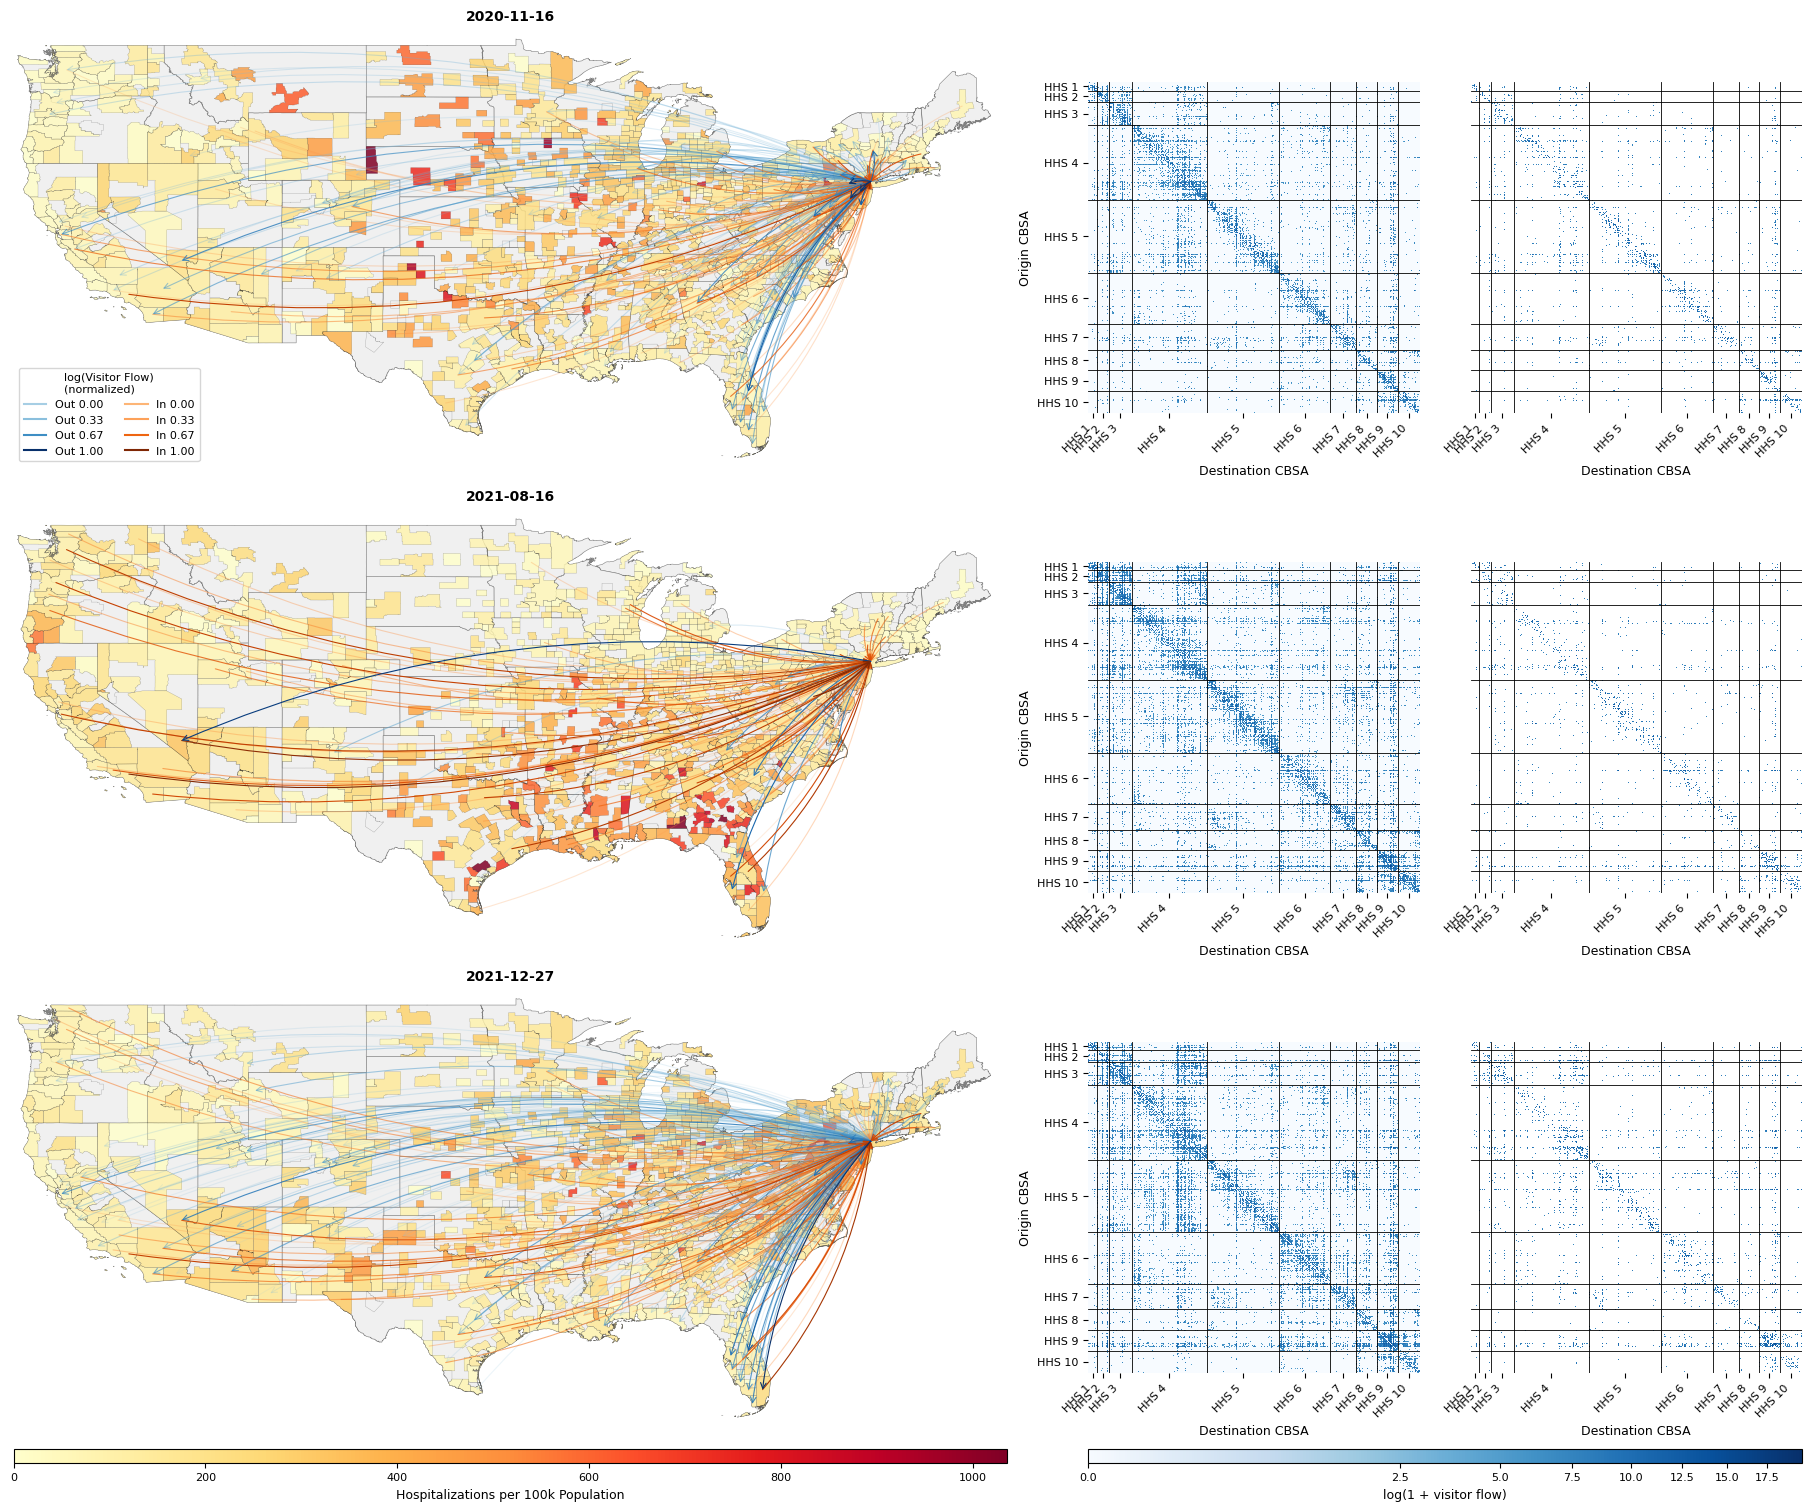

In [16]:
fig = plot_subgraph_heatmap_grid(
    dates=["2020-11-16", "2021-08-16", "2021-12-27"],
    explain_edges_df=explain_edges_df,
    importance_masks=importance_masks,
    hosp_df=hosp_df,
    hosp_col=hosp_col,
    date_col='collection_week',
    cbsa_col='CBSA',
    origin_cbsas=['35620'],
    dest_cbsas=['35620'],
    importance_threshold=0.5,
    curved_edges=True,
    save_path="fig3_maps_mobility.pdf",
)

## Notions of connectedness

## Retionaship between edge importance and edge weight

In [27]:
raw_advan_mobility = pd.read_csv(
    '/burg/apam/users/nhw2114/repos/cgnn/data/raw/mobility/advan_plus/all_advan_plus.csv',
    dtype={'cbsa_orig': str, 'cbsa_dest': str},
)
raw_advan_mobility['date_range_start'] = pd.to_datetime(raw_advan_mobility['date_range_start'])
raw_advan_mobility['date_range_end'] = pd.to_datetime(raw_advan_mobility['date_range_end'])

In [29]:
edge_weight_importance_df = importance_masks[['date','cbsa_orig','cbsa_dest','importance']].merge(
    raw_advan_mobility[['date_range_start', 'cbsa_orig', 'cbsa_dest', 'visitor_home_aggregation']],
    left_on=['date','cbsa_orig','cbsa_dest'],
    right_on=['date_range_start', 'cbsa_orig', 'cbsa_dest'],
    how='left'
)

In [33]:
edge_weight_importance_df = edge_weight_importance_df[~edge_weight_importance_df['visitor_home_aggregation'].isna()]
edge_weight_importance_df.head()

,date,cbsa_orig,cbsa_dest,importance,date_range_start,visitor_home_aggregation
0,2020-07-13,10100,10100,0.074471,2020-07-13,2223869.0
1,2020-07-13,10100,13900,0.145464,2020-07-13,10099.0
2,2020-07-13,10100,14460,0.158679,2020-07-13,26424.0
3,2020-07-13,10100,15100,0.160145,2020-07-13,9118.0
4,2020-07-13,10100,19740,0.157580,2020-07-13,1539.0


<Axes: xlabel='log_visitor_home_aggregation', ylabel='importance'>

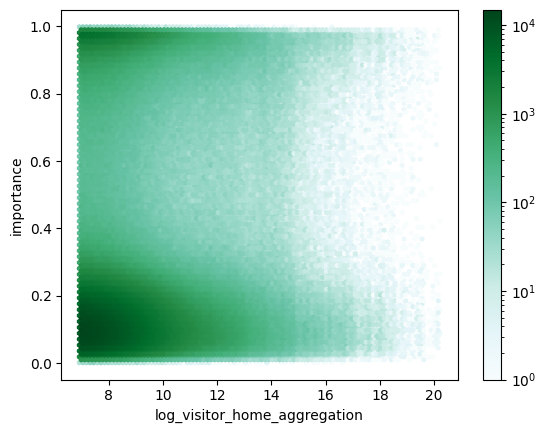

In [ ]:
edge_weight_importance_df['log_visitor_home_aggregation'] = np.log(edge_weight_importance_df['visitor_home_aggregation'])
edge_weight_importance_df[['importance','log_visitor_home_aggregation']].plot.hexbin(x='log_visitor_home_aggregation',y='importance', gridsize=100, norm=LogNorm())

## PCA

# Figure 4 - 